In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving metal_nut.zip to metal_nut.zip


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut"

print("Train folders:", os.listdir(dataset_path + "/train"))
print("Test folders:", os.listdir(dataset_path + "/test"))

print("\nTraining good images:",
      len(os.listdir(dataset_path + "/train/good")))

print("\nTest folders and image counts:")

for folder in os.listdir(dataset_path + "/test"):
    folder_path = os.path.join(dataset_path, "test", folder)
    print(folder, ":", len(os.listdir(folder_path)))

Train folders: ['good']
Test folders: ['bent', 'color', 'flip', 'good', 'scratch']

Training good images: 220

Test folders and image counts:
bent : 25
color : 22
flip : 23
good : 22
scratch : 23


In [ ]:
import torch
import torch.nn as nn
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/train",
    transform=transform
)

print("Total training images:", len(full_dataset))
print("Classes:", full_dataset.classes)

Total training images: 220
Classes: ['good']


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 176
Validation images: 44


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 11
Validation batches: 3


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Using device:", device)

Using device: cuda


In [ ]:
num_epochs = 25

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        reconstructed = model(images)

        loss = criterion(
            reconstructed,
            images
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/25], Loss: 0.0493
Epoch [2/25], Loss: 0.0231
Epoch [3/25], Loss: 0.0070
Epoch [4/25], Loss: 0.0043
Epoch [5/25], Loss: 0.0036
Epoch [6/25], Loss: 0.0030
Epoch [7/25], Loss: 0.0026
Epoch [8/25], Loss: 0.0024
Epoch [9/25], Loss: 0.0022
Epoch [10/25], Loss: 0.0020
Epoch [11/25], Loss: 0.0018
Epoch [12/25], Loss: 0.0016
Epoch [13/25], Loss: 0.0014
Epoch [14/25], Loss: 0.0012
Epoch [15/25], Loss: 0.0011
Epoch [16/25], Loss: 0.0011
Epoch [17/25], Loss: 0.0010
Epoch [18/25], Loss: 0.0010
Epoch [19/25], Loss: 0.0009
Epoch [20/25], Loss: 0.0009
Epoch [21/25], Loss: 0.0009
Epoch [22/25], Loss: 0.0008
Epoch [23/25], Loss: 0.0008
Epoch [24/25], Loss: 0.0008
Epoch [25/25], Loss: 0.0008


In [ ]:
save_dir = "/content/drive/MyDrive/Week7_Autoencoder"

model_path = os.path.join(
    save_dir,
    "autoencoder_model_v2.pth"
)

torch.save(model.state_dict(), model_path)

print("Model 1 saved successfully")
print("Saved at:", model_path)

Model 1 saved successfully
Saved at: /content/drive/MyDrive/Week7_Autoencoder/autoencoder_model_v2.pth


In [ ]:
model.eval()

val_errors = []

with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)

        reconstructed = model(images)

        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        val_errors.extend(errors.cpu().numpy())

val_errors = np.array(val_errors)

print("Validation images:", len(val_errors))
print("Min:", val_errors.min())
print("Max:", val_errors.max())
print("Mean:", val_errors.mean())
print("Median:", np.median(val_errors))

Validation images: 44
Min: 0.00048365077
Max: 0.001143968
Mean: 0.0007426901
Median: 0.0007301022


In [ ]:
threshold = np.percentile(val_errors, 95)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.0010262008


In [ ]:
test_dir = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/test"

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

Test images: 115
Classes: ['bent', 'color', 'flip', 'good', 'scratch']


In [ ]:
model.eval()

test_results = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        reconstructed = model(images)

        # Reconstruction error for each image
        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        for i in range(len(images)):

            error = errors[i].item()
            class_name = test_dataset.classes[labels[i].item()]

            prediction = (
                "Anomalous"
                if error > threshold
                else "Normal"
            )

            test_results.append({
                "class_name": class_name,
                "error": error,
                "prediction": prediction
            })

print("Evaluation completed.")
print("Total test images:", len(test_results))

Evaluation completed.
Total test images: 115


In [ ]:
import pandas as pd

results_df = pd.DataFrame(test_results)

summary = pd.crosstab(
    results_df["class_name"],
    results_df["prediction"]
)

print(summary)

prediction  Anomalous  Normal
class_name                   
bent                0      25
color               1      21
flip                0      23
good                3      19
scratch             0      23


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

true_labels = []
pred_labels = []

for result in test_results:
    true_labels.append(
        0 if result["class_name"] == "good" else 1
    )

    pred_labels.append(
        1 if result["prediction"] == "Anomalous" else 0
    )

cm = confusion_matrix(true_labels, pred_labels)

accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, zero_division=0)
recall = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Confusion Matrix:
[[19  3]
 [92  1]]

Accuracy : 0.17391304347826086
Precision: 0.25
Recall   : 0.010752688172043012
F1 Score : 0.020618556701030927


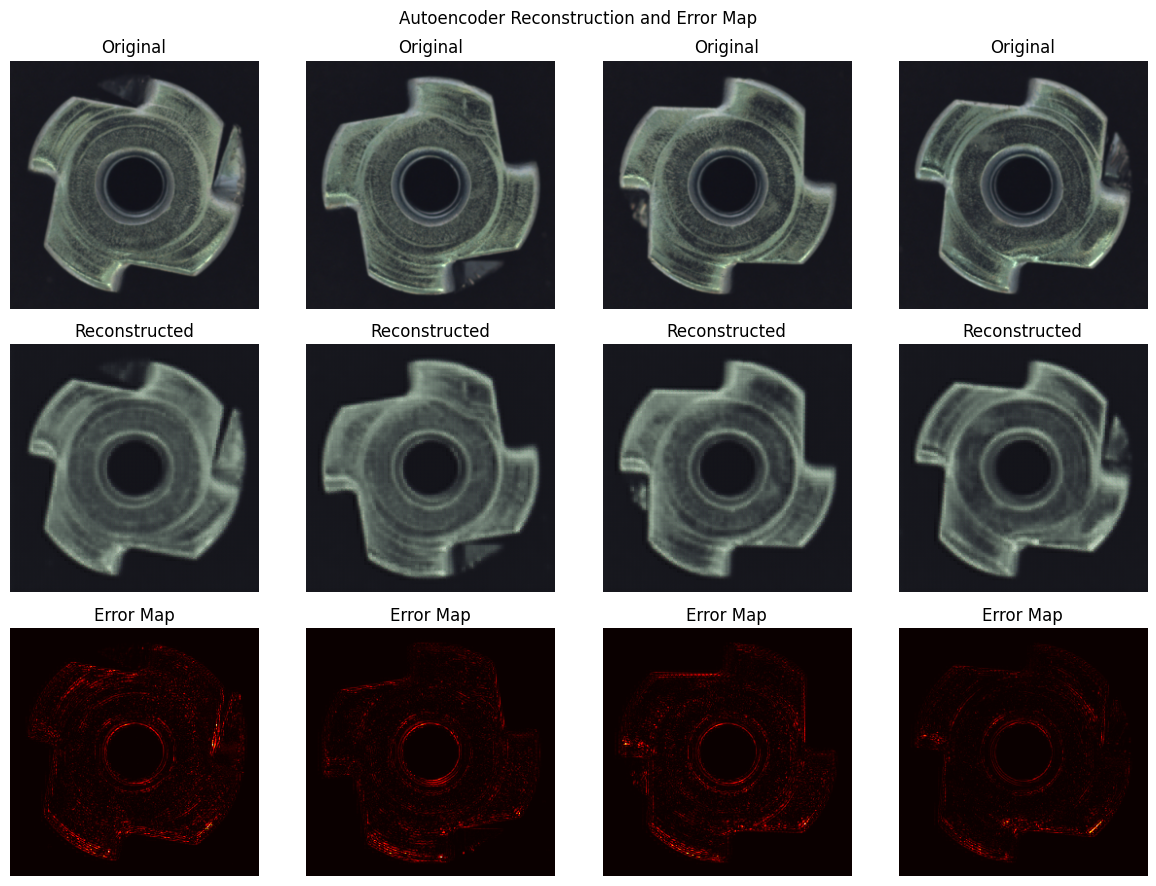

In [ ]:
model.eval()

images, labels = next(iter(test_loader))
images = images[:4].to(device)

with torch.no_grad():
    reconstructed = model(images)

# Pixel-wise reconstruction error
error = torch.mean((images - reconstructed) ** 2, dim=1)

plt.figure(figsize=(12, 9))

for i in range(4):

    # Original
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3, 4, i + 5)
    plt.imshow(reconstructed[i].cpu().permute(1, 2, 0))
    plt.title("Reconstructed")
    plt.axis("off")

    # Error map
    plt.subplot(3, 4, i + 9)
    plt.imshow(error[i].cpu(), cmap="hot")
    plt.title("Error Map")
    plt.axis("off")

plt.suptitle("Autoencoder Reconstruction and Error Map")
plt.tight_layout()
plt.show()

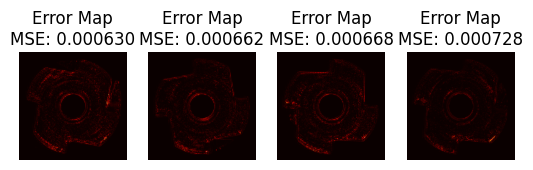

In [ ]:
error = torch.mean((images - reconstructed) ** 2, dim=1)

for i in range(4):
    mse_score = torch.mean((images[i] - reconstructed[i]) ** 2).item()

    plt.subplot(3, 4, i + 9)
    plt.imshow(error[i].cpu(), cmap="hot")
    plt.title(f"Error Map\nMSE: {mse_score:.6f}")
    plt.axis("off")

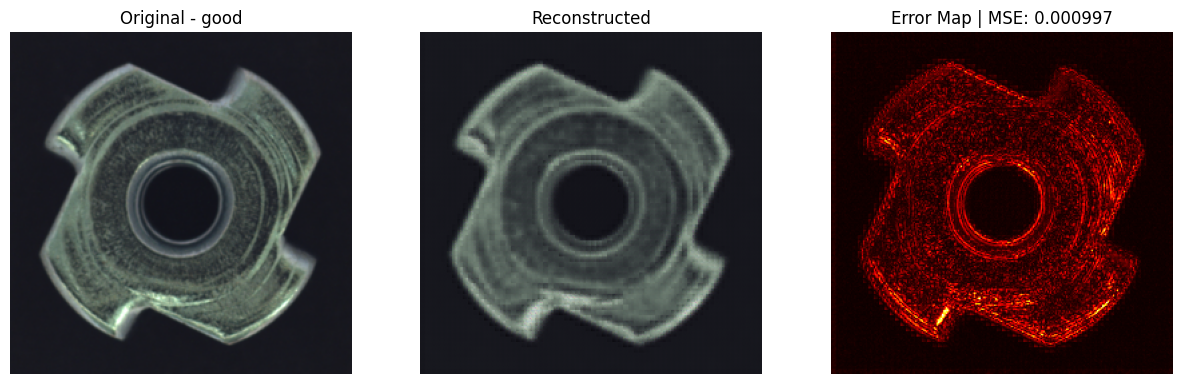

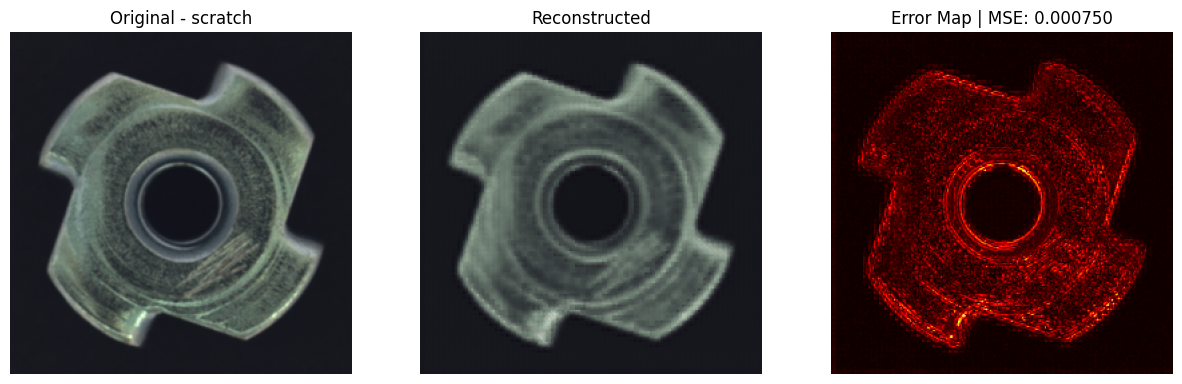

In [ ]:
def show_comparison(defect_type, image_name="000.png"):

    image_path = os.path.join(
        test_path,
        defect_type,
        image_name
    )

    original_pil = Image.open(image_path).convert("RGB")
    input_image = transform(original_pil).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        reconstructed = model(input_image)

    error_map = torch.mean(
        torch.abs(input_image - reconstructed),
        dim=1
    ).squeeze(0).cpu().numpy()

    original = input_image.squeeze(0).cpu().permute(1, 2, 0).numpy()
    reconstructed_img = reconstructed.squeeze(0).cpu().permute(1, 2, 0).numpy()

    mse = torch.mean(
        (input_image - reconstructed) ** 2
    ).item()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title(f"Original - {defect_type}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(reconstructed_img)
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(error_map, cmap="hot")
    plt.title(f"Error Map | MSE: {mse:.6f}")
    plt.axis("off")

    plt.show()


show_comparison("good")
show_comparison("scratch")

###Model 2 — Stronger Autoencoder

In [ ]:
class StrongerAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model2 = StrongerAutoencoder().to(device)

criterion2 = nn.MSELoss()

optimizer2 = torch.optim.Adam(
    model2.parameters(),
    lr=0.001
)

print(model2)

StrongerAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(2, 2

In [ ]:
num_epochs = 25

for epoch in range(num_epochs):

    model2.train()

    running_loss = 0.0
    val_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        reconstructed = model2(images)

        loss = criterion2(reconstructed, images)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()

    # Validation
    model2.eval()

    with torch.no_grad():

        for images, _ in val_loader:

            images = images.to(device)

            reconstructed = model2(images)

            loss = criterion2(reconstructed, images)

            val_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    validation_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {validation_loss:.4f}"
    )

Epoch [1/25], Train Loss: 0.0928, Val Loss: 0.0593
Epoch [2/25], Train Loss: 0.0466, Val Loss: 0.0277
Epoch [3/25], Train Loss: 0.0208, Val Loss: 0.0145
Epoch [4/25], Train Loss: 0.0151, Val Loss: 0.0141
Epoch [5/25], Train Loss: 0.0133, Val Loss: 0.0123
Epoch [6/25], Train Loss: 0.0112, Val Loss: 0.0097
Epoch [7/25], Train Loss: 0.0087, Val Loss: 0.0080
Epoch [8/25], Train Loss: 0.0073, Val Loss: 0.0063
Epoch [9/25], Train Loss: 0.0061, Val Loss: 0.0055
Epoch [10/25], Train Loss: 0.0054, Val Loss: 0.0049
Epoch [11/25], Train Loss: 0.0049, Val Loss: 0.0045
Epoch [12/25], Train Loss: 0.0045, Val Loss: 0.0041
Epoch [13/25], Train Loss: 0.0041, Val Loss: 0.0038
Epoch [14/25], Train Loss: 0.0039, Val Loss: 0.0036
Epoch [15/25], Train Loss: 0.0037, Val Loss: 0.0034
Epoch [16/25], Train Loss: 0.0035, Val Loss: 0.0033
Epoch [17/25], Train Loss: 0.0033, Val Loss: 0.0031
Epoch [18/25], Train Loss: 0.0032, Val Loss: 0.0030
Epoch [19/25], Train Loss: 0.0031, Val Loss: 0.0029
Epoch [20/25], Train 

In [ ]:
model2_path = os.path.join(
    save_dir,
    "stronger_autoencoder.pth"
)

torch.save(
    model2.state_dict(),
    model2_path
)

print("Model 2 saved successfully")
print("Saved at:", model2_path)

Model 2 saved successfully
Saved at: /content/drive/MyDrive/Week7_Autoencoder/stronger_autoencoder.pth


In [ ]:
model2.eval()

val_errors2 = []

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        reconstructed = model2(images)

        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        val_errors2.extend(
            errors.cpu().numpy()
        )

print("Validation images:", len(val_errors2))
print("Minimum:", min(val_errors2))
print("Maximum:", max(val_errors2))
print("Mean:", np.mean(val_errors2))
print("Median:", np.median(val_errors2))

Validation images: 44
Minimum: 0.0015868613
Maximum: 0.004251179
Mean: 0.0024869235
Median: 0.002465298


In [ ]:
threshold2 = np.percentile(
    val_errors2,
    95
)

print("Model 2 anomaly threshold:", threshold2)

Model 2 anomaly threshold: 0.0033592437


In [ ]:
model2.eval()

test_results2 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        reconstructed = model2(images)

        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        for error, label in zip(errors, labels):

            error_value = error.item()

            prediction = (
                "Anomalous"
                if error_value > threshold2
                else "Normal"
            )

            class_name = test_dataset.classes[
                label.item()
            ]

            test_results2.append({
                "class_name": class_name,
                "error": error_value,
                "prediction": prediction
            })

print("Model 2 testing completed.")

Model 2 testing completed.


In [ ]:
results_df2 = pd.DataFrame(test_results2)

category_summary2 = pd.crosstab(
    results_df2["class_name"],
    results_df2["prediction"]
)

print(category_summary2)

prediction  Anomalous  Normal
class_name                   
bent                0      25
color               3      19
flip                0      23
good                5      17
scratch             0      23


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = []
y_pred = []

for result in test_results2:

    if result["class_name"] == "good":
        y_true.append(0)
    else:
        y_true.append(1)

    if result["prediction"] == "Normal":
        y_pred.append(0)
    else:
        y_pred.append(1)

cm = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Confusion Matrix:
[[17  5]
 [90  3]]
Accuracy : 0.17391304347826086
Precision: 0.375
Recall   : 0.03225806451612903
F1 Score : 0.0594059405940594


###Model 3 — PatchCore-style Anomaly Detection

In [ ]:
from torchvision import models
import torch.nn as nn

weights = models.ResNet18_Weights.DEFAULT

resnet = models.resnet18(weights=weights)

resnet = resnet.to(device)
resnet.eval()

feature_extractor = nn.Sequential(
    *list(resnet.children())[:-2]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet18 feature extractor ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.6MB/s]


ResNet18 feature extractor ready


In [ ]:
sample_images, _ = next(iter(train_loader))

sample_images = sample_images[:1].to(device)

with torch.no_grad():
    features = feature_extractor(sample_images)

print("Input shape:", sample_images.shape)
print("Feature map shape:", features.shape)

Input shape: torch.Size([1, 3, 256, 256])
Feature map shape: torch.Size([1, 512, 8, 8])


In [ ]:
def extract_features(loader):

    all_features = []

    feature_extractor.eval()

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            features = feature_extractor(images)

            # [B, 512, 8, 8]
            features = features.permute(
                0, 2, 3, 1
            )

            # [B, 64, 512]
            features = features.reshape(
                features.shape[0],
                -1,
                features.shape[-1]
            )

            all_features.append(
                features.cpu()
            )

    return torch.cat(all_features, dim=0)


train_features = extract_features(train_loader)

print("Training feature shape:", train_features.shape)

Training feature shape: torch.Size([176, 64, 512])


In [ ]:
memory_bank = train_features.reshape(
    -1,
    train_features.shape[-1]
)

print("Memory bank shape:", memory_bank.shape)

Memory bank shape: torch.Size([11264, 512])


In [ ]:
val_features = extract_features(val_loader)

print("Validation feature shape:", val_features.shape)

Validation feature shape: torch.Size([44, 64, 512])


In [ ]:
def calculate_patchcore_scores(
    features,
    memory_bank
):

    scores = []

    for image_features in features:

        distances = torch.cdist(
            image_features,
            memory_bank
        )

        nearest_distances = distances.min(
            dim=1
        ).values

        image_score = nearest_distances.max()

        scores.append(
            image_score.item()
        )

    return scores


val_scores = calculate_patchcore_scores(
    val_features,
    memory_bank
)

print("Validation images:", len(val_scores))
print("Minimum score:", min(val_scores))
print("Maximum score:", max(val_scores))
print("Mean score:", np.mean(val_scores))
print("Median score:", np.median(val_scores))

Validation images: 44
Minimum score: 9.773821830749512
Maximum score: 22.44637107849121
Mean score: 17.145519841801036
Median score: 17.055007934570312


In [ ]:
threshold_patchcore = np.percentile(
    val_scores,
    95
)

print(
    "PatchCore-style anomaly threshold:",
    threshold_patchcore
)

PatchCore-style anomaly threshold: 21.40024175643921


In [ ]:
test_features = extract_features(test_loader)

print("Test feature shape:", test_features.shape)

Test feature shape: torch.Size([115, 64, 512])


In [ ]:
test_scores = calculate_patchcore_scores(
    test_features,
    memory_bank
)

print("Number of test scores:", len(test_scores))

Number of test scores: 115


In [ ]:
patchcore_results = []

for i, score in enumerate(test_scores):

    label = test_dataset.targets[i]

    class_name = test_dataset.classes[label]

    prediction = (
        "Anomalous"
        if score > threshold_patchcore
        else "Normal"
    )

    patchcore_results.append({
        "class_name": class_name,
        "score": score,
        "prediction": prediction
    })

print("PatchCore-style predictions completed.")
print("Total predictions:", len(patchcore_results))

PatchCore-style predictions completed.
Total predictions: 115


In [ ]:
y_true_patchcore = []
y_pred_patchcore = []

for result in patchcore_results:

    if result["class_name"] == "good":
        y_true_patchcore.append(0)
    else:
        y_true_patchcore.append(1)

    if result["prediction"] == "Normal":
        y_pred_patchcore.append(0)
    else:
        y_pred_patchcore.append(1)


cm_patchcore = confusion_matrix(
    y_true_patchcore,
    y_pred_patchcore
)

accuracy_patchcore = accuracy_score(
    y_true_patchcore,
    y_pred_patchcore
)

precision_patchcore = precision_score(
    y_true_patchcore,
    y_pred_patchcore
)

recall_patchcore = recall_score(
    y_true_patchcore,
    y_pred_patchcore
)

f1_patchcore = f1_score(
    y_true_patchcore,
    y_pred_patchcore
)

print("Confusion Matrix:")
print(cm_patchcore)

print("Accuracy :", accuracy_patchcore)
print("Precision:", precision_patchcore)
print("Recall   :", recall_patchcore)
print("F1 Score :", f1_patchcore)

Confusion Matrix:
[[21  1]
 [40 53]]
Accuracy : 0.6434782608695652
Precision: 0.9814814814814815
Recall   : 0.5698924731182796
F1 Score : 0.7210884353741497


In [ ]:
patchcore_df = pd.DataFrame(patchcore_results)

print("PatchCore DataFrame created.")
print(patchcore_df.head())
print("Total rows:", len(patchcore_df))

PatchCore DataFrame created.
  class_name      score prediction
0       bent  21.862898  Anomalous
1       bent  19.407492     Normal
2       bent  20.537701     Normal
3       bent  21.003334     Normal
4       bent  15.329542     Normal
Total rows: 115


In [ ]:
results_path = os.path.join(
    save_dir,
    "patchcore_results.csv"
)

patchcore_df.to_csv(
    results_path,
    index=False
)

print("Results saved at:")
print(results_path)

Results saved at:
/content/drive/MyDrive/Week7_Autoencoder/patchcore_results.csv


###Model 3 :PaDiM

In [ ]:
# PaDiM: Extract feature maps from normal training images

def extract_padim_features(loader):

    all_features = []

    feature_extractor.eval()

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            features = feature_extractor(images)

            all_features.append(features.cpu())

    return torch.cat(all_features, dim=0)


train_padim_features = extract_padim_features(train_loader)
val_padim_features = extract_padim_features(val_loader)
test_padim_features = extract_padim_features(test_loader)

print("Train features:", train_padim_features.shape)
print("Validation features:", val_padim_features.shape)
print("Test features:", test_padim_features.shape)

Train features: torch.Size([176, 512, 8, 8])
Validation features: torch.Size([44, 512, 8, 8])
Test features: torch.Size([115, 512, 8, 8])


In [ ]:
# Rearrange features:
# [images, channels, height, width]
# → [images, spatial_locations, channels]

train_padim_features = train_padim_features.permute(0, 2, 3, 1)
val_padim_features = val_padim_features.permute(0, 2, 3, 1)
test_padim_features = test_padim_features.permute(0, 2, 3, 1)

train_padim_features = train_padim_features.reshape(176, 64, 512)
val_padim_features = val_padim_features.reshape(44, 64, 512)
test_padim_features = test_padim_features.reshape(115, 64, 512)

print("Train:", train_padim_features.shape)
print("Validation:", val_padim_features.shape)
print("Test:", test_padim_features.shape)

Train: torch.Size([176, 64, 512])
Validation: torch.Size([44, 64, 512])
Test: torch.Size([115, 64, 512])


In [ ]:
# Select 100 feature dimensions to reduce computation

torch.manual_seed(42)

selected_features = torch.randperm(512)[:100]

train_selected = train_padim_features[:, :, selected_features]
val_selected = val_padim_features[:, :, selected_features]
test_selected = test_padim_features[:, :, selected_features]

print("Selected train features:", train_selected.shape)

Selected train features: torch.Size([176, 64, 100])


In [ ]:
# Learn the normal feature distribution at each spatial location

mean_features = train_selected.mean(dim=0)

covariances = []

for location in range(64):

    location_features = train_selected[:, location, :]

    covariance = torch.cov(
        location_features.T
    )

    covariance = covariance + 0.001 * torch.eye(100)

    covariances.append(covariance)

covariances = torch.stack(covariances)

print("Mean shape:", mean_features.shape)
print("Covariance shape:", covariances.shape)

Mean shape: torch.Size([64, 100])
Covariance shape: torch.Size([64, 100, 100])


In [ ]:
# Calculate anomaly score using Mahalanobis distance

def calculate_padim_scores(features):

    image_scores = []

    for image in features:

        patch_scores = []

        for location in range(64):

            feature = image[location]
            mean = mean_features[location]
            covariance = covariances[location]

            diff = feature - mean

            inverse_covariance = torch.linalg.pinv(covariance)

            distance = torch.sqrt(
                diff @ inverse_covariance @ diff
            )

            patch_scores.append(distance.item())

        image_score = max(patch_scores)

        image_scores.append(image_score)

    return image_scores

In [ ]:
# Calculate scores for normal validation images

val_padim_scores = calculate_padim_scores(
    val_selected
)

threshold_padim = np.percentile(
    val_padim_scores,
    95
)

print("Validation images:", len(val_padim_scores))
print("Minimum:", min(val_padim_scores))
print("Maximum:", max(val_padim_scores))
print("Mean:", np.mean(val_padim_scores))
print("Median:", np.median(val_padim_scores))
print("PaDiM Threshold:", threshold_padim)

Validation images: 44
Minimum: 14.57429313659668
Maximum: 54.39490509033203
Mean: 23.565678856589578
Median: 21.361071586608887
PaDiM Threshold: 38.1473913192749


In [ ]:
# Test PaDiM on unseen defect types

test_padim_scores = calculate_padim_scores(
    test_selected
)

padim_results = []

for i, score in enumerate(test_padim_scores):

    label = test_dataset.targets[i]
    class_name = test_dataset.classes[label]

    prediction = (
        "Anomalous"
        if score > threshold_padim
        else "Normal"
    )

    padim_results.append({
        "class_name": class_name,
        "score": score,
        "prediction": prediction
    })

print("PaDiM predictions completed.")
print("Total predictions:", len(padim_results))

PaDiM predictions completed.
Total predictions: 115


In [ ]:
padim_df = pd.DataFrame(padim_results)

padim_summary = pd.crosstab(
    padim_df["class_name"],
    padim_df["prediction"]
)

print(padim_summary)

prediction  Anomalous  Normal
class_name                   
bent               16       9
color               7      15
flip               23       0
good                0      22
scratch            12      11


In [ ]:
padim_results_path = os.path.join(
    save_dir,
    "padim_results.csv"
)

padim_df.to_csv(
    padim_results_path,
    index=False
)

print("PaDiM results saved at:")
print(padim_results_path)

PaDiM results saved at:
/content/drive/MyDrive/Week7_Autoencoder/padim_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [ ]:
from torchvision import models

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
).to(device)

feature_extractor = torch.nn.Sequential(
    *list(resnet.children())[:-2]
).to(device)

feature_extractor.eval()

print("Feature extractor loaded successfully.")

Feature extractor loaded successfully.


In [ ]:
import os
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

train_dir = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/train"

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    train_dir,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

all_features = []

with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)

        features = feature_extractor(images)

        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        all_features.append(features.cpu())

train_features = torch.cat(all_features, dim=0)

memory_bank = train_features.reshape(
    -1,
    train_features.shape[-1]
)

print("Memory bank shape:", memory_bank.shape)

Memory bank shape: torch.Size([14080, 512])


In [ ]:


train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [176, 44],
    generator=torch.Generator().manual_seed(42)
)

train_loader_patchcore = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False
)

train_features = []

with torch.no_grad():
    for images, _ in train_loader_patchcore:
        images = images.to(device)

        features = feature_extractor(images)

        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        train_features.append(features.cpu())

train_features = torch.cat(train_features, dim=0)

memory_bank = train_features.reshape(
    -1,
    train_features.shape[-1]
)

print("Correct memory bank shape:", memory_bank.shape)

Correct memory bank shape: torch.Size([11264, 512])


In [ ]:


val_loader_patchcore = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

val_features = []

with torch.no_grad():
    for images, _ in val_loader_patchcore:
        images = images.to(device)

        features = feature_extractor(images)

        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        val_features.append(features.cpu())

val_features = torch.cat(val_features, dim=0)

val_scores = []

for image_features in val_features:

    distances = torch.cdist(
        image_features,
        memory_bank
    )

    nearest_distances = distances.min(dim=1).values

    val_scores.append(
        nearest_distances.max().item()
    )

threshold_patchcore = np.percentile(
    val_scores,
    95
)

print("Correct PatchCore Threshold:", threshold_patchcore)

Correct PatchCore Threshold: 21.4002760887146


Saving 004.png to 004.png
Anomaly Score : 17.0611
Threshold     : 21.4003
Prediction    : Normal


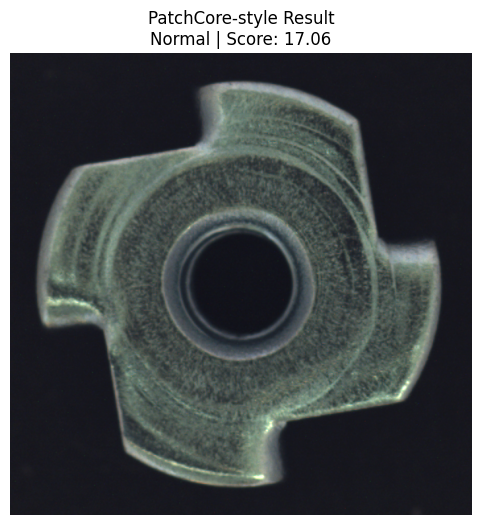

In [ ]:
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


uploaded = files.upload()
image_path = "/content/" + list(uploaded.keys())[0]


image = Image.open(image_path).convert("RGB")


transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

image_tensor = transform(image).unsqueeze(0).to(device)


feature_extractor.eval()

with torch.no_grad():
    features = feature_extractor(image_tensor)

features = features.permute(0, 2, 3, 1)
features = features.reshape(1, -1, features.shape[-1])


distances = torch.cdist(
    features[0],
    memory_bank
)

nearest_distances = distances.min(dim=1).values
anomaly_score = nearest_distances.max().item()


prediction = (
    "Anomalous"
    if anomaly_score > threshold_patchcore
    else "Normal"
)

print("Anomaly Score :", round(anomaly_score, 4))
print("Threshold     :", round(threshold_patchcore, 4))
print("Prediction    :", prediction)


plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"PatchCore-style Result\n"
    f"{prediction} | Score: {anomaly_score:.2f}"
)
plt.axis("off")
plt.show()

In [ ]:
# Improved PatchCore: ResNet18 Layer2 + Layer3 features

import torch
import torch.nn.functional as F
from torchvision import models

resnet_l23 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
).to(device)

resnet_l23.eval()

def extract_l23(images):
    x = resnet_l23.conv1(images)
    x = resnet_l23.bn1(x)
    x = resnet_l23.relu(x)
    x = resnet_l23.maxpool(x)

    x = resnet_l23.layer1(x)

    layer2_features = resnet_l23.layer2(x)
    layer3_features = resnet_l23.layer3(layer2_features)

    # Resize Layer 3 to Layer 2 spatial size
    layer3_features = F.interpolate(
        layer3_features,
        size=layer2_features.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Combine both feature levels
    combined_features = torch.cat(
        [layer2_features, layer3_features],
        dim=1
    )

    return combined_features

print("Improved feature extractor ready.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


NameError: name 'device' is not defined

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

train_dir = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/train"

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    train_dir,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Classes:", train_dataset.classes)

Training images: 220
Classes: ['good']


In [ ]:
# Step 2: Build improved PatchCore memory bank

from torch.utils.data import DataLoader

# Same 176 normal training images + 44 validation images
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [176, 44],
    generator=torch.Generator().manual_seed(42)
)

train_loader_improved = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False
)

improved_train_features = []

with torch.no_grad():
    for images, _ in train_loader_improved:
        images = images.to(device)

        features = extract_l23(images)

        # [batch, channels, height, width]
        # → [batch, patches, features]
        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        improved_train_features.append(features.cpu())

improved_train_features = torch.cat(
    improved_train_features,
    dim=0
)

# Create memory bank
improved_memory_bank = improved_train_features.reshape(
    -1,
    improved_train_features.shape[-1]
)

print("Training feature shape:", improved_train_features.shape)
print("Improved memory bank shape:", improved_memory_bank.shape)

Training feature shape: torch.Size([176, 1024, 384])
Improved memory bank shape: torch.Size([180224, 384])


In [ ]:
# Step 3: Create a representative coreset
# We keep 10,000 normal patches instead of all 180,224.

import torch

torch.manual_seed(42)

num_coreset = 10000

indices = torch.randperm(
    improved_memory_bank.shape[0]
)[:num_coreset]

coreset_memory_bank = improved_memory_bank[indices]

print("Original memory bank:", improved_memory_bank.shape)
print("Coreset memory bank:", coreset_memory_bank.shape)

Original memory bank: torch.Size([180224, 384])
Coreset memory bank: torch.Size([10000, 384])


In [ ]:
# Step 4: Extract improved features from validation images

from torch.utils.data import DataLoader

val_loader_improved = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

improved_val_features = []

with torch.no_grad():
    for images, _ in val_loader_improved:
        images = images.to(device)

        features = extract_l23(images)

        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        improved_val_features.append(features.cpu())

improved_val_features = torch.cat(
    improved_val_features,
    dim=0
)

print("Validation feature shape:", improved_val_features.shape)

Validation feature shape: torch.Size([44, 1024, 384])


In [ ]:


import numpy as np

improved_val_scores = []

for image_features in improved_val_features:

    patch_scores = []

    # Process patches in smaller chunks to avoid high memory usage
    for start in range(0, image_features.shape[0], 128):

        patch_chunk = image_features[start:start + 128]

        distances = torch.cdist(
            patch_chunk,
            coreset_memory_bank
        )

        nearest_distances = distances.min(dim=1).values

        patch_scores.extend(
            nearest_distances.tolist()
        )

    # Image anomaly score = largest patch anomaly score
    image_score = max(patch_scores)

    improved_val_scores.append(image_score)

# 95th percentile threshold
improved_threshold_patchcore = np.percentile(
    improved_val_scores,
    95
)

print("Validation images:", len(improved_val_scores))
print("Minimum score:", min(improved_val_scores))
print("Maximum score:", max(improved_val_scores))
print("Mean score:", np.mean(improved_val_scores))
print("Median score:", np.median(improved_val_scores))
print("Improved PatchCore Threshold:", improved_threshold_patchcore)

Validation images: 44
Minimum score: 2.7708091735839844
Maximum score: 3.642359733581543
Mean score: 3.145765169100328
Median score: 3.1473339796066284
Improved PatchCore Threshold: 3.4487438559532166


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

week7_path = "/content/drive/MyDrive/Week7_Autoencoder"

print(os.listdir(week7_path))

['metal_nut.zip', 'metal_nut', 'autoencoder_model.pth', 'autoencoder_model_v2.pth', 'stronger_autoencoder.pth', 'patchcore_results.csv', 'padim_results.csv', 'patchcore_features', 'patchcore_improved']


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models

# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Load pretrained ResNet18
resnet_l23 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
).to(device)

resnet_l23.eval()

# Function for Layer2 + Layer3 feature extraction
def extract_l23(images):
    x = resnet_l23.conv1(images)
    x = resnet_l23.bn1(x)
    x = resnet_l23.relu(x)
    x = resnet_l23.maxpool(x)

    x = resnet_l23.layer1(x)

    layer2_features = resnet_l23.layer2(x)
    layer3_features = resnet_l23.layer3(layer2_features)

    # Resize Layer3 to Layer2 spatial size
    layer3_features = F.interpolate(
        layer3_features,
        size=layer2_features.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Combine Layer2 + Layer3
    combined_features = torch.cat(
        [layer2_features, layer3_features],
        dim=1
    )

    return combined_features

print("Improved Layer2 + Layer3 extractor ready.")

Using device: cuda
Improved Layer2 + Layer3 extractor ready.


In [ ]:
# Step 3: Recreate dataset split and extract improved features

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import os


train_dir = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/train"

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    train_dir,
    transform=transform
)


train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [176, 44],
    generator=torch.Generator().manual_seed(42)
)

train_loader_improved = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False
)

val_loader_improved = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

# Extract training features
improved_train_features = []

with torch.no_grad():
    for images, _ in train_loader_improved:
        images = images.to(device)

        features = extract_l23(images)

        features = features.permute(0, 2, 3, 1)
        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        improved_train_features.append(features.cpu())

improved_train_features = torch.cat(
    improved_train_features,
    dim=0
)

# Extract validation features
improved_val_features = []

with torch.no_grad():
    for images, _ in val_loader_improved:
        images = images.to(device)

        features = extract_l23(images)

        features = features.permute(0, 2, 3, 1)
        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        improved_val_features.append(features.cpu())

improved_val_features = torch.cat(
    improved_val_features,
    dim=0
)

# Save features to Drive
feature_save_dir = "/content/drive/MyDrive/Week7_Autoencoder/patchcore_features"
os.makedirs(feature_save_dir, exist_ok=True)

torch.save(
    improved_train_features,
    os.path.join(
        feature_save_dir,
        "layer2_layer3_train_features.pt"
    )
)

torch.save(
    improved_val_features,
    os.path.join(
        feature_save_dir,
        "layer2_layer3_val_features.pt"
    )
)

print("Training features:", improved_train_features.shape)
print("Validation features:", improved_val_features.shape)
print("Features saved to Google Drive.")

Training features: torch.Size([176, 1024, 384])
Validation features: torch.Size([44, 1024, 384])
Features saved to Google Drive.


In [ ]:
# Recreate the same 10,000-patch coreset

torch.manual_seed(42)

improved_memory_bank = improved_train_features.reshape(
    -1,
    improved_train_features.shape[-1]
)

num_coreset = 10000

indices = torch.randperm(
    improved_memory_bank.shape[0]
)[:num_coreset]

coreset_memory_bank = improved_memory_bank[indices]

print("Original memory bank:", improved_memory_bank.shape)
print("Coreset memory bank:", coreset_memory_bank.shape)

Original memory bank: torch.Size([180224, 384])
Coreset memory bank: torch.Size([10000, 384])


In [ ]:
# Step 5: Improved PatchCore validation score + threshold

import numpy as np
import torch

improved_val_scores = []

for image_features in improved_val_features:

    patch_scores = []

    for start in range(0, image_features.shape[0], 128):

        patch_chunk = image_features[start:start + 128]

        distances = torch.cdist(
            patch_chunk,
            coreset_memory_bank
        )

        nearest_distances = distances.min(dim=1).values

        patch_scores.extend(
            nearest_distances.tolist()
        )

    # Highest patch score = image-level anomaly score
    image_score = max(patch_scores)

    improved_val_scores.append(image_score)

# 95th percentile threshold
improved_threshold_patchcore = np.percentile(
    improved_val_scores,
    95
)

print("Validation images:", len(improved_val_scores))
print("Minimum:", min(improved_val_scores))
print("Maximum:", max(improved_val_scores))
print("Mean:", np.mean(improved_val_scores))
print("Median:", np.median(improved_val_scores))
print("Improved PatchCore Threshold:", improved_threshold_patchcore)

Validation images: 44
Minimum: 2.7708091735839844
Maximum: 3.6423542499542236
Mean: 3.145765255797993
Median: 3.1473329067230225
Improved PatchCore Threshold: 3.4487432479858398


In [ ]:
# Step 6: Test improved PatchCore on all 115 test images

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import pandas as pd

test_dir = "/content/drive/MyDrive/Week7_Autoencoder/metal_nut/test"

test_dataset = ImageFolder(
    test_dir,
    transform=transform
)

test_loader_improved = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

improved_test_features = []

with torch.no_grad():
    for images, _ in test_loader_improved:

        images = images.to(device)

        features = extract_l23(images)

        features = features.permute(0, 2, 3, 1)

        features = features.reshape(
            features.shape[0],
            -1,
            features.shape[-1]
        )

        improved_test_features.append(
            features.cpu()
        )

improved_test_features = torch.cat(
    improved_test_features,
    dim=0
)

print("Test feature shape:", improved_test_features.shape)

# Calculate anomaly scores
improved_test_scores = []

for image_features in improved_test_features:

    patch_scores = []

    for start in range(0, image_features.shape[0], 128):

        patch_chunk = image_features[start:start + 128]

        distances = torch.cdist(
            patch_chunk,
            coreset_memory_bank
        )

        nearest_distances = distances.min(dim=1).values

        patch_scores.extend(
            nearest_distances.tolist()
        )

    image_score = max(patch_scores)

    improved_test_scores.append(image_score)

# Create predictions
improved_patchcore_results = []

for i, score in enumerate(improved_test_scores):

    true_class = test_dataset.classes[
        test_dataset.targets[i]
    ]

    prediction = (
        "Anomalous"
        if score > improved_threshold_patchcore
        else "Normal"
    )

    improved_patchcore_results.append({
        "class_name": true_class,
        "score": score,
        "prediction": prediction
    })

improved_patchcore_df = pd.DataFrame(
    improved_patchcore_results
)

print("\nPredictions completed.")
print("Total images:", len(improved_patchcore_df))

Test feature shape: torch.Size([115, 1024, 384])

Predictions completed.
Total images: 115


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Class-wise summary
improved_summary = pd.crosstab(
    improved_patchcore_df["class_name"],
    improved_patchcore_df["prediction"]
)

print("Class-wise Results:")
print(improved_summary)

# Convert to binary labels
y_true = []
y_pred = []

for result in improved_patchcore_results:

    # Good = Normal, all other classes = Anomalous
    if result["class_name"] == "good":
        y_true.append(0)
    else:
        y_true.append(1)

    if result["prediction"] == "Normal":
        y_pred.append(0)
    else:
        y_pred.append(1)

# Metrics
cm = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Class-wise Results:
prediction  Anomalous  Normal
class_name                   
bent               23       2
color              15       7
flip               23       0
good                4      18
scratch            12      11

Confusion Matrix:
[[18  4]
 [20 73]]

Accuracy : 0.7913043478260869
Precision: 0.948051948051948
Recall   : 0.7849462365591398
F1 Score : 0.8588235294117647


In [ ]:


import os
import torch

save_dir = "/content/drive/MyDrive/Week7_Autoencoder/patchcore_improved"
os.makedirs(save_dir, exist_ok=True)

bundle_path = os.path.join(
    save_dir,
    "patchcore_improved_bundle.pth"
)

torch.save(
    {
        "resnet_state_dict": resnet_l23.state_dict(),
        "coreset_memory_bank": coreset_memory_bank,
        "threshold": float(improved_threshold_patchcore)
    },
    bundle_path
)

# Also save the test results
improved_patchcore_df.to_csv(
    os.path.join(
        save_dir,
        "improved_patchcore_results.csv"
    ),
    index=False
)

print("PatchCore setup saved successfully.")
print("Saved at:")
print(bundle_path)

PatchCore setup saved successfully.
Saved at:
/content/drive/MyDrive/Week7_Autoencoder/patchcore_improved/patchcore_improved_bundle.pth


In [ ]:
# Improved PatchCore threshold
threshold_patchcore = 3.4487432479858398

print("PatchCore threshold:", threshold_patchcore)

PatchCore threshold: 3.4487432479858398


In [ ]:


coreset_memory_bank = coreset_memory_bank.to(device)

patch_scores = []

for start in range(
    0,
    features.shape[1],
    128
):

    patch_chunk = features[
        0,
        start:start + 128
    ]   # Do NOT use .cpu()

    distances = torch.cdist(
        patch_chunk,
        coreset_memory_bank
    )

    nearest_distances = distances.min(dim=1).values

    patch_scores.extend(
        nearest_distances.detach().cpu().tolist()
    )

anomaly_score = max(patch_scores)

prediction = (
    "Anomalous"
    if anomaly_score > threshold_patchcore
    else "Normal"
)

print("\n--------------------------------")
print("Anomaly Score :", round(anomaly_score, 4))
print("Threshold     :", round(threshold_patchcore, 4))
print("Prediction    :", prediction)
print("--------------------------------")


--------------------------------
Anomaly Score : 3.1461
Threshold     : 3.4487
Prediction    : Normal
--------------------------------


Saving 014.png to 014.png
Uploaded image: 014.png

--------------------------------
Anomaly Score : 3.1838
Threshold     : 3.4487
Prediction    : Normal
--------------------------------


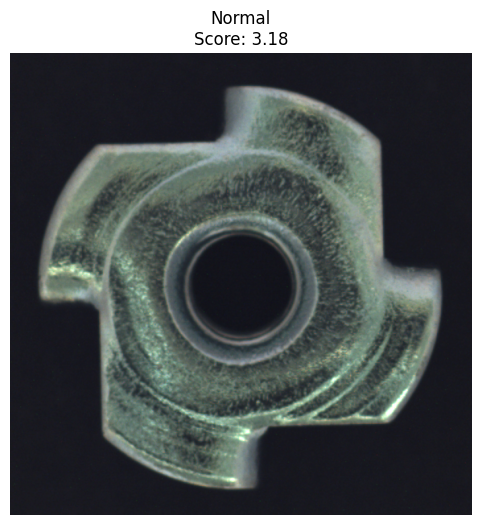

In [ ]:


from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Upload a NEW image
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

#  Open image
image = Image.open(image_path).convert("RGB")

# Convert image to tensor
image_tensor = transform(
    image
).unsqueeze(0).to(device)

# Extract Layer2 + Layer3 features
with torch.no_grad():
    features = extract_l23(image_tensor)

features = features.permute(0, 2, 3, 1)

features = features.reshape(
    1,
    -1,
    features.shape[-1]
)

# Keep memory bank on same device
coreset_memory_bank = coreset_memory_bank.to(device)

#  Calculate anomaly score
patch_scores = []

for start in range(0, features.shape[1], 128):

    patch_chunk = features[
        0,
        start:start + 128
    ]

    distances = torch.cdist(
        patch_chunk,
        coreset_memory_bank
    )

    nearest_distances = distances.min(dim=1).values

    patch_scores.extend(
        nearest_distances.detach().cpu().tolist()
    )

anomaly_score = max(patch_scores)

#  Prediction
prediction = (
    "Anomalous"
    if anomaly_score > threshold_patchcore
    else "Normal"
)

print("\n--------------------------------")
print("Anomaly Score :", round(anomaly_score, 4))
print("Threshold     :", round(threshold_patchcore, 4))
print("Prediction    :", prediction)
print("--------------------------------")

# 8. Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"{prediction}\nScore: {anomaly_score:.2f}"
)
plt.axis("off")
plt.show()

Saving 018.png to 018.png
Uploaded image: 018.png

--------------------------------
Anomaly Score : 4.0889
Threshold     : 3.4487
Prediction    : Anomalous
--------------------------------


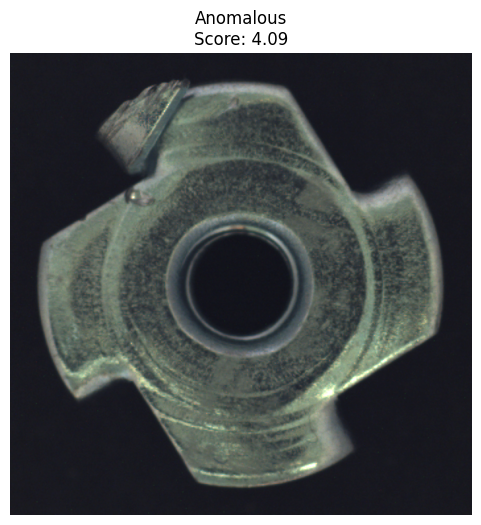

In [ ]:
# Week 7 – Improved PatchCore Live Testing

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Upload a NEW image
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

#  Open image
image = Image.open(image_path).convert("RGB")

#  Convert image to tensor
image_tensor = transform(
    image
).unsqueeze(0).to(device)

#Extract Layer2 + Layer3 features
with torch.no_grad():
    features = extract_l23(image_tensor)

features = features.permute(0, 2, 3, 1)

features = features.reshape(
    1,
    -1,
    features.shape[-1]
)

# Keep memory bank on same device
coreset_memory_bank = coreset_memory_bank.to(device)

#  Calculate anomaly score
patch_scores = []

for start in range(0, features.shape[1], 128):

    patch_chunk = features[
        0,
        start:start + 128
    ]

    distances = torch.cdist(
        patch_chunk,
        coreset_memory_bank
    )

    nearest_distances = distances.min(dim=1).values

    patch_scores.extend(
        nearest_distances.detach().cpu().tolist()
    )

anomaly_score = max(patch_scores)

# Prediction
prediction = (
    "Anomalous"
    if anomaly_score > threshold_patchcore
    else "Normal"
)

print("\n--------------------------------")
print("Anomaly Score :", round(anomaly_score, 4))
print("Threshold     :", round(threshold_patchcore, 4))
print("Prediction    :", prediction)
print("--------------------------------")

#  Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"{prediction}\nScore: {anomaly_score:.2f}"
)
plt.axis("off")
plt.show()